# Setup

In [1]:
# from google.colab import userdata

# GIT_TOKEN = userdata.get('GH_TOKEN')
# REPO_URL = f"https://{GIT_TOKEN}@github.com/Vlad-Andres/HCML-project.git"

# !rm -rf temp_repo
# !git clone {REPO_URL} temp_repo
# !cp -r temp_repo/* .
# !rm -rf temp_repo
# !ls -F

In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.inspection import permutation_importance, PartialDependenceDisplay
from pathlib import Path
from src import config, visualization, data_loader, feature_engineering, modeling, fairness, visualization, explainability

In [3]:
import shap
import xgboost

print(shap.__version__)
print(xgboost.__version__)

0.49.1
2.1.4


# Load data

In [ ]:
DATA_DIR = data_loader.resolve_data_dir()
OUTPUT_DIR = Path("/content/oulad_outputs") if Path("/content").exists() else Path("oulad_outputs")
OUTPUT_DIR.mkdir(parents=True, exist_ok=True)
CONCISE_MODE = False
tables = data_loader.load_all_tables(DATA_DIR)
# data_loader.inspect_tables(tables["student_info"], tables["courses"])

Downloaded dataset to: /Users/Mutru001/.cache/kagglehub/datasets/anlgrbz/student-demographics-online-education-dataoulad/versions/1
Reading courses.csv from /Users/Mutru001/.cache/kagglehub/datasets/anlgrbz/student-demographics-online-education-dataoulad/versions/1/courses.csv
Reading assessments.csv from /Users/Mutru001/.cache/kagglehub/datasets/anlgrbz/student-demographics-online-education-dataoulad/versions/1/assessments.csv
Reading studentAssessment.csv from /Users/Mutru001/.cache/kagglehub/datasets/anlgrbz/student-demographics-online-education-dataoulad/versions/1/studentAssessment.csv
Reading studentInfo.csv from /Users/Mutru001/.cache/kagglehub/datasets/anlgrbz/student-demographics-online-education-dataoulad/versions/1/studentInfo.csv
Reading studentRegistration.csv from /Users/Mutru001/.cache/kagglehub/datasets/anlgrbz/student-demographics-online-education-dataoulad/versions/1/studentRegistration.csv
Reading studentVle.csv from /Users/Mutru001/.cache/kagglehub/datasets/anlgrbz/

In [5]:
base = feature_engineering.build_base_table(tables["student_info"], tables["courses"])
early_df = feature_engineering.build_dataset_for_stage(
    base, tables["student_vle"], tables["vle"], tables["courses"],
    tables["student_assess"], tables["assessments"], tables["student_reg"],
    fraction=0.25, stage_name="early_25pct"
)
full_df = feature_engineering.build_dataset_for_stage(
    base, tables["student_vle"], tables["vle"], tables["courses"],
    tables["student_assess"], tables["assessments"], tables["student_reg"],
    fraction=1.00, stage_name="full_100pct"
)
if not CONCISE_MODE:
    display(early_df.head()); display(full_df.head())


Base table shape: (32593, 14)
Target distribution:
target_unsuccessful
1    17208
0    15385
Name: count, dtype: int64
target_unsuccessful
1    0.527966
0    0.472034
Name: proportion, dtype: float64

Building dataset for early_25pct, fraction=0.25
VLE features: (28360, 18)
Assessment features: (25444, 11)
Registration features: (32593, 6)
Final stage table: (32593, 39)

Building dataset for full_100pct, fraction=1.0
VLE features: (28500, 18)
Assessment features: (25843, 11)
Registration features: (32593, 6)
Final stage table: (32593, 39)


In [6]:
train_students, test_students = modeling.student_train_test_split(base)
early_train, early_test = modeling.apply_split(early_df, train_students, test_students)
full_train,  full_test  = modeling.apply_split(full_df,  train_students, test_students)
perf_early, models_early = modeling.fit_and_evaluate_stage("early_25pct", early_train, early_test)
perf_full,  models_full  = modeling.fit_and_evaluate_stage("full_100pct", full_train, full_test)
performance_table = pd.concat([perf_early, perf_full], ignore_index=True)[[
    "stage", "model", "accuracy", "balanced_accuracy",
    "precision_at_risk", "recall_at_risk", "f1_at_risk", "roc_auc"
]]
if not CONCISE_MODE:
    display(performance_table.sort_values(["model", "stage"]))

Training LogisticRegression for early_25pct...
Training RandomForest for early_25pct...
Training XGBoost for early_25pct...
Training LogisticRegression for full_100pct...
Training RandomForest for full_100pct...
Training XGBoost for full_100pct...


# Analysis

## Fairness

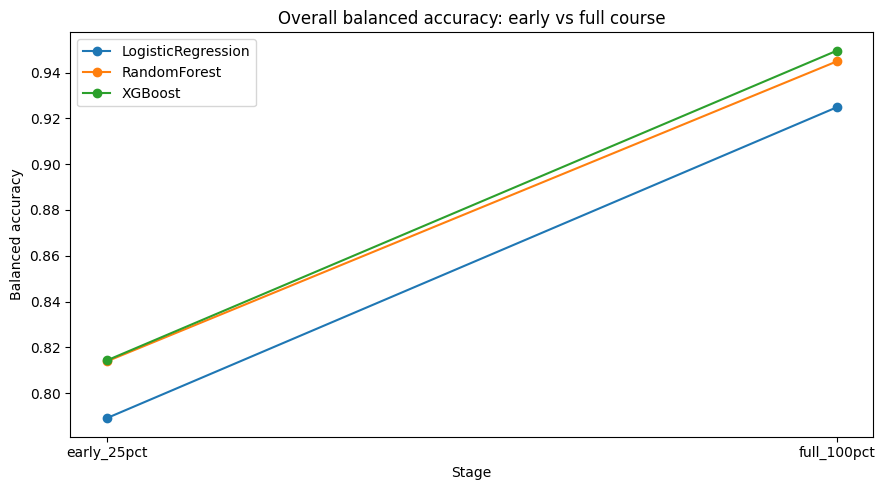

Saved: oulad_outputs/overall_balanced_accuracy_by_stage.png


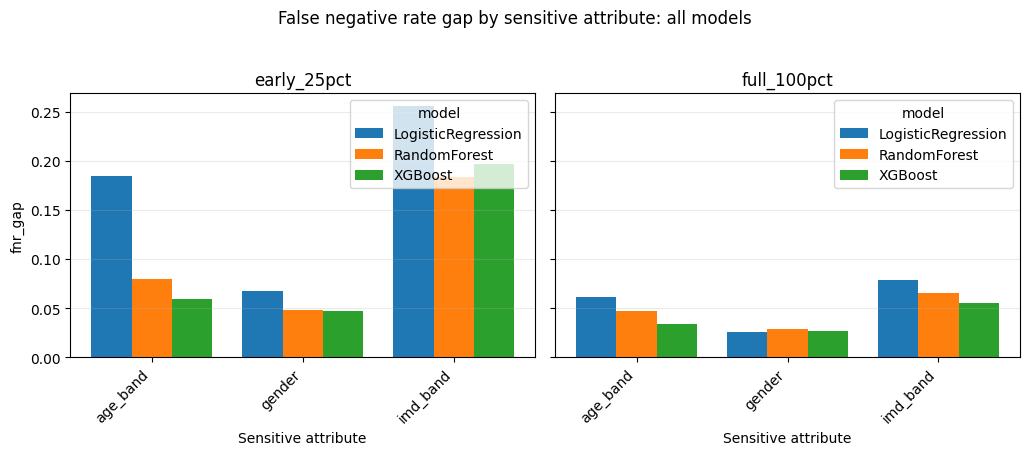

Saved: oulad_outputs/fnr_gap_all_models.png


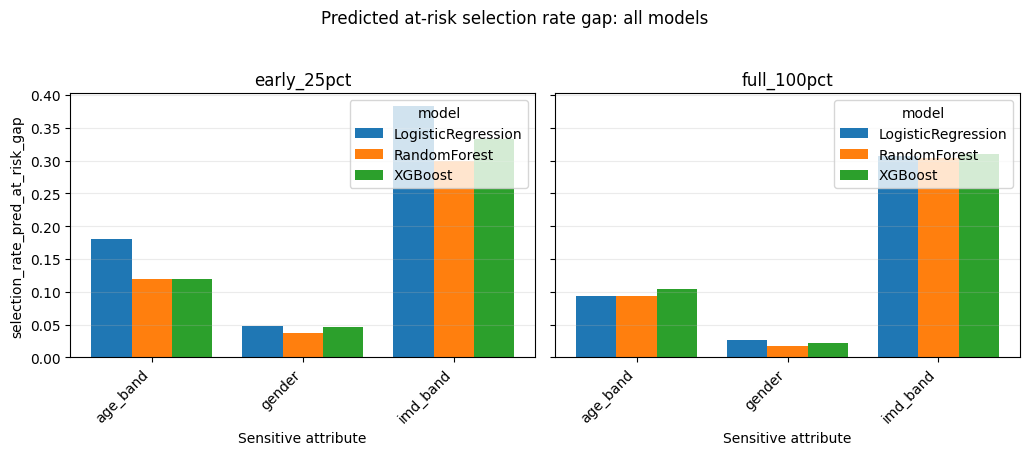

Saved: oulad_outputs/selection_rate_gap_all_models.png


In [7]:
subgroup_early = fairness.run_fairness_analysis("early_25pct", early_test, models_early)
subgroup_full  = fairness.run_fairness_analysis("full_100pct", full_test,  models_full)
subgroup_metrics = pd.concat([subgroup_early, subgroup_full], ignore_index=True)
fairness_gaps = fairness.fairness_gap_summary(subgroup_metrics)
# display(subgroup_metrics.head(30))
# display(fairness_gaps.sort_values(["model", "sensitive_attr", "stage"]))

visualization.plot_overall_performance(performance_table, OUTPUT_DIR)
# visualization.plot_fairness_gaps(fairness_gaps, OUTPUT_DIR)
visualization.plot_combined_fairness_gaps(fairness_gaps, OUTPUT_DIR)

## Explainability

Saved: oulad_outputs/pfi_combined_models_early_25pct.png


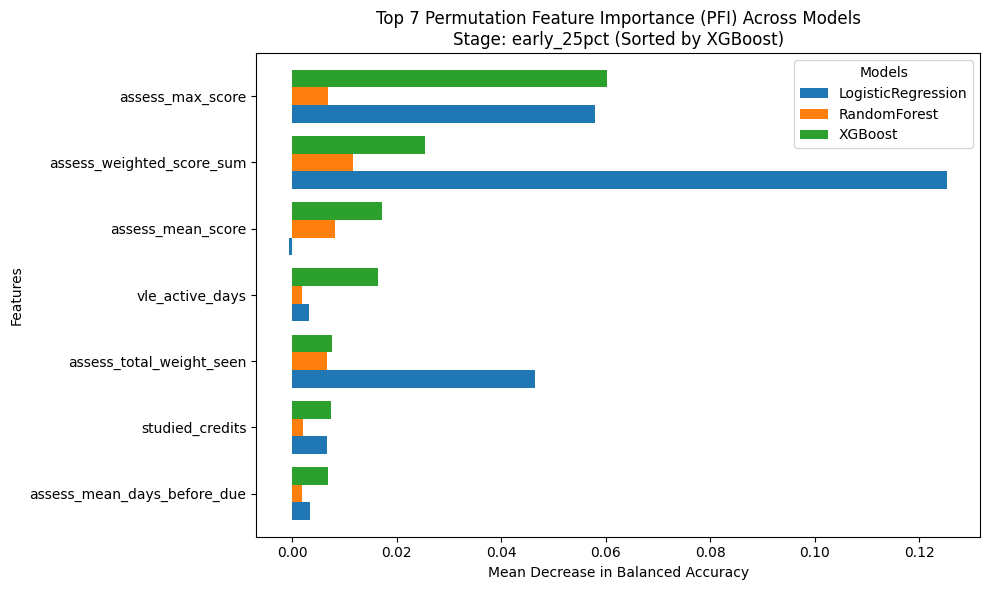

Saved: oulad_outputs/pfi_combined_models_full_25pct.png


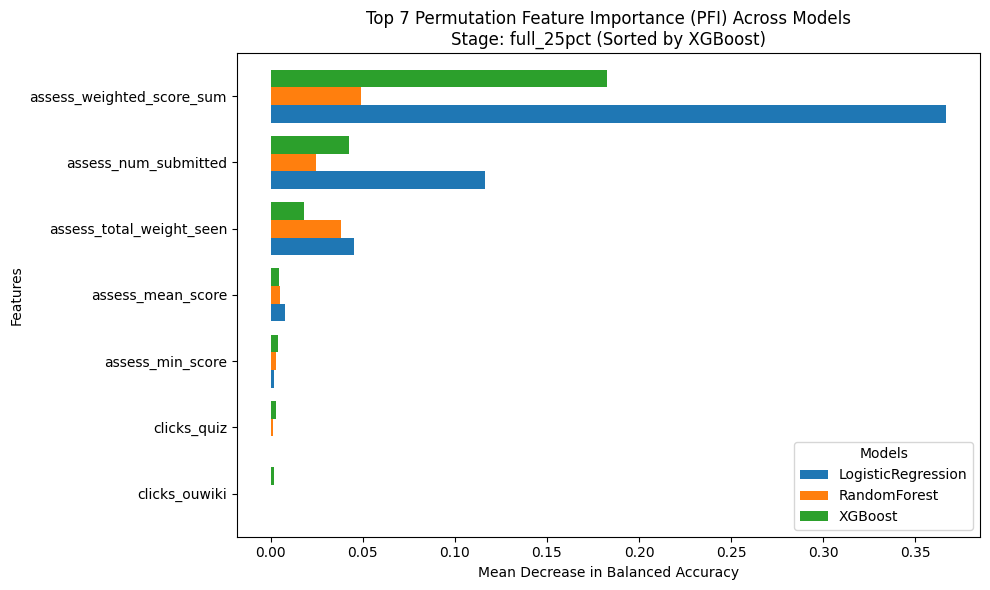

In [ ]:
from importlib import reload

from src.explainability import (
    run_shap_for_tree_model,
    compute_family_importance,
    plot_family_importance,
    subgroup_shap_comparison,
    run_permutation_importance,
    run_partial_dependence,
    plot_shap_distributions,
    plot_combined_shap_comparison,
    plot_combined_pfi_comparison
)

# plot_shap_distributions(models_early, early_test, sample_size=800, output_dir=OUTPUT_DIR)
# plot_shap_distributions(models_full, full_test, sample_size=800, output_dir=OUTPUT_DIR)
# plot_combined_shap_comparison(models_early, early_test, "early_25pct", output_dir=OUTPUT_DIR)
# plot_combined_shap_comparison(models_full, full_test, "full_100pct", output_dir=OUTPUT_DIR)
plot_combined_pfi_comparison(models_early, early_test, "early_25pct", 7, output_dir=OUTPUT_DIR)
plot_combined_pfi_comparison(models_full, full_test, "full_100pct", 7, output_dir=OUTPUT_DIR)

if not CONCISE_MODE:
    shap_results = {}
    for model_name, pipe in models_early.items():
        shap_results[(model_name, "early_25pct")] = run_shap_for_tree_model(
            pipe,
            early_test,
            "early_25pct",
            model_name,
            output_dir=OUTPUT_DIR,
        )
    for model_name, pipe in models_full.items():
        shap_results[(model_name, "full_100pct")] = run_shap_for_tree_model(
            pipe,
            full_test,
            "full_100pct",
            model_name,
            output_dir=OUTPUT_DIR,
        )

    family_importance = compute_family_importance(shap_results)
    plot_family_importance(family_importance, output_dir=OUTPUT_DIR)

    common_tree_models = [
        model_name for model_name in ["RandomForest", "XGBoost"]
        if model_name in models_early and model_name in models_full
    ]

    if common_tree_models:
        pdp_features = ["vle_total_clicks", "vle_active_days", "studied_credits"]
        valid_features_early = [f for f in pdp_features if f in early_test.columns]
        valid_features_full = [f for f in pdp_features if f in full_test.columns]

        for model_name in common_tree_models:
            subgroup_shap_comparison(
                models_early[model_name],
                early_test,
                "highest_education",
                "early_25pct",
                model_name,
                output_dir=OUTPUT_DIR,
            )
            subgroup_shap_comparison(
                models_early[model_name],
                early_test,
                "imd_band",
                "early_25pct",
                model_name,
                output_dir=OUTPUT_DIR,
            )

            run_permutation_importance(
                models_early[model_name],
                early_test,
                "early_25pct",
                model_name,
                output_dir=OUTPUT_DIR,
            )
            run_permutation_importance(
                models_full[model_name],
                full_test,
                "full_100pct",
                model_name,
                output_dir=OUTPUT_DIR,
            )

            if valid_features_early:
                run_partial_dependence(
                    models_early[model_name],
                    early_test,
                    "early_25pct",
                    model_name,
                    valid_features_early,
                    output_dir=OUTPUT_DIR,
                )
                run_partial_dependence(
                    models_early[model_name],
                    early_test,
                    "early_25pct",
                    model_name,
                    valid_features_early,
                    centered=True,
                    output_dir=OUTPUT_DIR,
                )
            if valid_features_full:
                run_partial_dependence(
                    models_full[model_name],
                    full_test,
                    "full_100pct",
                    model_name,
                    valid_features_full,
                    output_dir=OUTPUT_DIR,
                )
                run_partial_dependence(
                    models_full[model_name],
                    full_test,
                    "full_100pct",
                    model_name,
                    valid_features_full,
                    centered=True,
                    output_dir=OUTPUT_DIR,
                )
    else:
        print("No shared tree models are available for extra explainability.")


In [9]:
from src.reporting import export_tables

export_tables(performance_table, subgroup_metrics, fairness_gaps,
              family_importance=family_importance, output_dir=OUTPUT_DIR)

NameError: name 'family_importance' is not defined